In [7]:
import geopandas as gpd

In [8]:
schools = gpd.read_file("schools_original.gpkg")

In [9]:
import pandas as pd
from shapely.geometry import Point

# New Canillo schools – coordinates in WGS84 (EPSG:4326)
new_schools_data = [
    {"name": "Escola Andorrana de Canillo", "amenity": "school",
     "geometry": Point(1 + 35/60 + 52.6/3600, 42 + 34/60 + 4.0/3600)},
    {"name": "Escola Francesa de Canillo",  "amenity": "school",
     "geometry": Point(1 + 35/60 + 53.6/3600, 42 + 34/60 + 4.3/3600)},
]

new_schools = gpd.GeoDataFrame(new_schools_data, crs="EPSG:4326")

# Reproject to match the existing schools layer
new_schools = new_schools.to_crs(schools.crs)

# Append and reset index
schools = gpd.GeoDataFrame(
    pd.concat([schools, new_schools], ignore_index=True),
    crs=schools.crs
)

schools.tail()

,type,id,nodes,amenity,check_date,name,name:ca,website,wikidata,wikipedia,addr:city,addr:postcode,addr:street,building:levels,geometry
23,way,1.059804e+09,"[9737154055, 9737154054, 9737154053, 973715405...",school,None,Col·legi de la Peletera (Escola Francesa d'Esc...,None,None,None,None,None,None,None,None,POINT (380232.729 4707610.976)
24,way,1.144344e+09,"[10651650519, 10651650520, 10651650521, 106516...",school,None,None,None,None,None,None,None,None,None,None,POINT (383524.318 4710336.652)
25,way,1.174086e+09,"[10909384494, 10909384493, 10909384492, 109093...",school,None,Escola Andorrana,None,None,None,None,None,None,None,None,POINT (376131.664 4702505.536)
26,NaN,NaN,NaN,school,NaN,Escola Andorrana de Canillo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (384922.022 4713771.635)
27,NaN,NaN,NaN,school,NaN,Escola Francesa de Canillo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (384944.975 4713780.511)


In [10]:
schools.to_file("schools.gpkg",driver = "GPKG")

In [11]:
street = gpd.read_file("level_of_service_streets.gpkg")

<Axes: >

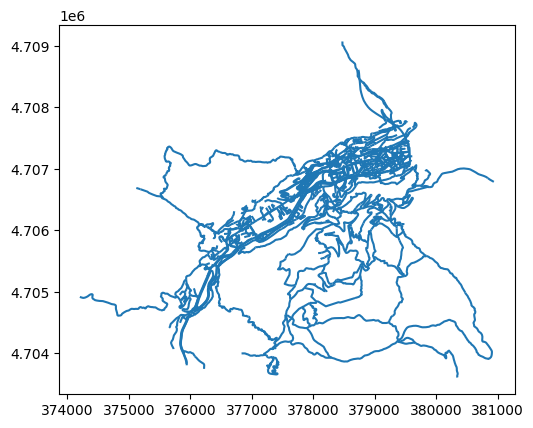

In [12]:
street.plot()